In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/Users/chenxu/Work/comm-ls")

import os, sys
os.chdir(ROOT)

In [2]:
SLEEVE_CONFIG = {
    "psx_ref": {
        "tickers": ["PSX"],
        "feature": "activity_deferred_annualized_carry_chg_21d",
        "threshold": 0.01,
        "side_mult": 1,
        "mode": "fixed_hold",
        "hold_days": 10,
        "weights": {'PSX': 1.0},
    },
    "refiner": {
        "tickers": ["DINO", "DK", "PBF"],
        # "tickers": ["DINO", "DK"],
        "feature": "front_third_annualized_carry_chg_21d",
        "threshold": 0.01,
        "side_mult": 1,
        "mode": "fixed_hold",
        "hold_days": 10,
        "weights": {'DK': 0.4, 'DINO': 0.3, 'PBF': 0.3},
        # "weights": {'DK': 0.6, 'DINO': 0.4},
    },
    "fuel": {
        "tickers": ["MUSA", "CASY"],
        # "feature": "front_third_spread",
        "feature": "front_third_annualized_carry",
        "threshold": 0.06,
        "side_mult": -1,
        "mode": "fixed_hold",
        "hold_days": 10,
        "weights": {'MUSA': 0.4, 'CASY': 0.6},
    },
    "service": {
        "tickers": ["FTI", "OII", "SLB", "HAL"],
        "feature": "carry_chg_21d",
        "threshold": 0.10,
        "side_mult": -1,
        "mode": "sign",
        "hold_days": None,
        "weights": {"FTI": 0.25, "OII": 0.25, "SLB": 0.25, "HAL": 0.25},
    },
    "shipping": {
        "tickers": ["DHT", "FRO", "TNK", "STNG", "INSW"],
        'feature': 'carry',
        "threshold": 0.01,
        "side_mult": -1,
        "mode": "fixed_hold",
        "hold_days": 10,
        "weights": {'DHT': 0.3, 'FRO': 0.3, 'TNK': 0.15, 'STNG': 0.05, 'INSW': 0.2},
    },
    "chemical": {
        "tickers": ["AVNT", "CE", "DOW", "EMN", "HUN", "LYB", "WLK"],
        "feature": "carry",
        "threshold": 0.02,
        "side_mult": 1,
        "mode": "sign",
        "hold_days": 21,
        "weights": {'AVNT': 0.05, 'CE': 0.1, 'DOW': 0.2, 'EMN': 0.1, 'HUN': 0.1, 'LYB': 0.25, 'WLK': 0.2},
    },
    "metals": {
        "tickers": ["ATI", "CRS"],
        # "tickers": ["ATI", "CRS", "MTRN", "HWM"],
        'feature': 'next_dec_annualized_carry_gap_le_9m_v2',
        "threshold": 0.015,
        "side_mult": -1,
        "mode": "fixed_hold",
        "hold_days": 21,
        "weights": {'ATI': 0.55, 'CRS': 0.45},
        # "weights": {'ATI': 0.45, 'CRS': 0.35, 'MTRN': 0.2, 'HWM': 0.},
    },
    "bwt": {
        "tickers": ["ERO", "TECK"],
        "feature": "brent_wti_carry_spread",
        "threshold": 0.02,
        "side_mult": -1,
        "mode": "sign",
        "hold_days": None,
        "weights": {'ERO': 0.5, 'TECK': 0.5},
    },
}


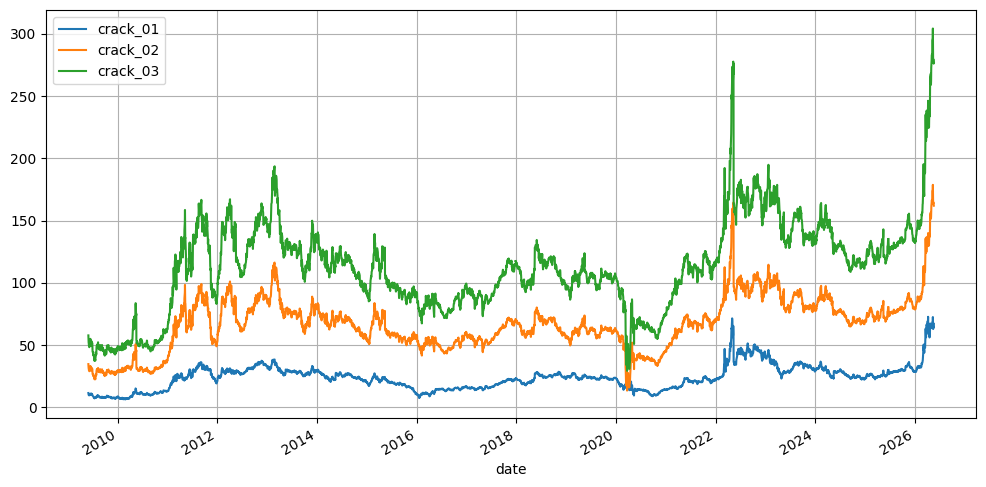

In [95]:
def load_crack_month(month: str = 'M', roll_by: str = 'open int') -> pd.DataFrame:
    root_dir = Path('data/comm/')

    data_cl = {}
    data_ho = {}
    data_rb = {}

    for yr in range(2010, 2027):
        path_cl = root_dir / 'CL' / f'{yr}{month}.csv'
        path_ho = root_dir / 'HO' / f'{yr}{month}.csv'
        path_rb = root_dir / 'XB' / f'{yr}{month}.csv'

        df_cl = pd.read_csv(path_cl, index_col='date', parse_dates=['date']).sort_index()
        df_ho = pd.read_csv(path_ho, index_col='date', parse_dates=['date']).sort_index()
        df_rb = pd.read_csv(path_rb, index_col='date', parse_dates=['date']).sort_index()

        df_cl['ret'] = np.log(df_cl['px_settle']).diff()
        df_ho['ret'] = np.log(df_ho['px_settle']).diff()
        df_rb['ret'] = np.log(df_rb['px_settle']).diff()

        data_cl[f'{yr}{month}'] = df_cl.copy()
        data_ho[f'{yr}{month}'] = df_ho.copy()
        data_rb[f'{yr}{month}'] = df_rb.copy()


    volumes: dict[str, pd.Series] = {}
    for sym, df in data_cl.items():
        volumes[sym] = df[roll_by].rolling(3, min_periods=1).mean()

    df_vol = pd.DataFrame(volumes)
    columns = sorted(df_vol.columns)
    df_vol = df_vol[columns]

    settles_cl, returns_cl = [], []
    settles_ho, returns_ho = [], []
    settles_rb, returns_rb = [], []

    start = None
    for i in range(len(columns) - 1):
        col1, col2 = columns[i], columns[i + 1]
        df_tmp = df_vol.loc[df_vol[col1] >= df_vol[col2]]
        if not len(df_tmp) > 0: continue
        end = df_tmp.index[-1]

        if start is None:
            start = df_tmp.index[0]

        first_cl = data_cl[col1]
        first_ho = data_ho[col1]
        first_rb = data_rb[col1]

        df_cl = first_cl.loc[(first_cl.index >= start) & (first_cl.index < end)]
        df_ho = first_ho.loc[(first_ho.index >= start) & (first_ho.index < end)]
        df_rb = first_rb.loc[(first_rb.index >= start) & (first_rb.index < end)]

        settles_cl += df_cl['px_settle'],
        returns_cl += df_cl['ret'],
        settles_ho += df_ho['px_settle'],
        returns_ho += df_ho['ret'],
        settles_rb += df_rb['px_settle'],
        returns_rb += df_rb['ret'],

        start = end

    last_cl = data_cl[columns[-1]]
    settles_cl += last_cl.loc[last_cl.index >= start]['px_settle'],
    returns_cl += last_cl.loc[last_cl.index >= start]['ret'],

    last_ho = data_ho[columns[-1]]
    settles_ho += last_ho.loc[last_ho.index >= start]['px_settle'],
    returns_ho += last_ho.loc[last_ho.index >= start]['ret'],

    last_rb = data_rb[columns[-1]]
    settles_rb += last_rb.loc[last_rb.index >= start]['px_settle'],
    returns_rb += last_rb.loc[last_rb.index >= start]['ret'],


    df_res = pd.DataFrame({
        'cl_settle': pd.concat(settles_cl),
        'ho_settle': pd.concat(settles_ho),
        'rb_settle': pd.concat(settles_rb),
        'cl_ret': pd.concat(returns_cl),
        'ho_ret': pd.concat(returns_ho),
        'rb_ret': pd.concat(returns_rb),
    }).sort_index()

    df_res['crack_01'] = df_res['ho_settle'] / 100 * 42  - df_res['cl_settle']
    df_res['crack_02'] = df_res['rb_settle'] / 100. * 42 * 2 + df_res['ho_settle'] / 100. * 42 * 1 - df_res['cl_settle'] * 3.
    df_res['crack_03'] = df_res['rb_settle'] / 100. * 42 * 3 + df_res['ho_settle'] / 100. * 42 * 2 - df_res['cl_settle'] * 5.

    return df_res


df_m = load_crack_month('M')
df_z = load_crack_month('Z')



df_m[['crack_01', 'crack_02', 'crack_03']].plot(figsize=(12, 6), grid=True)

crack = df_m['crack_01']

PnL    1.660537
Net    1.543537
dtype: float64

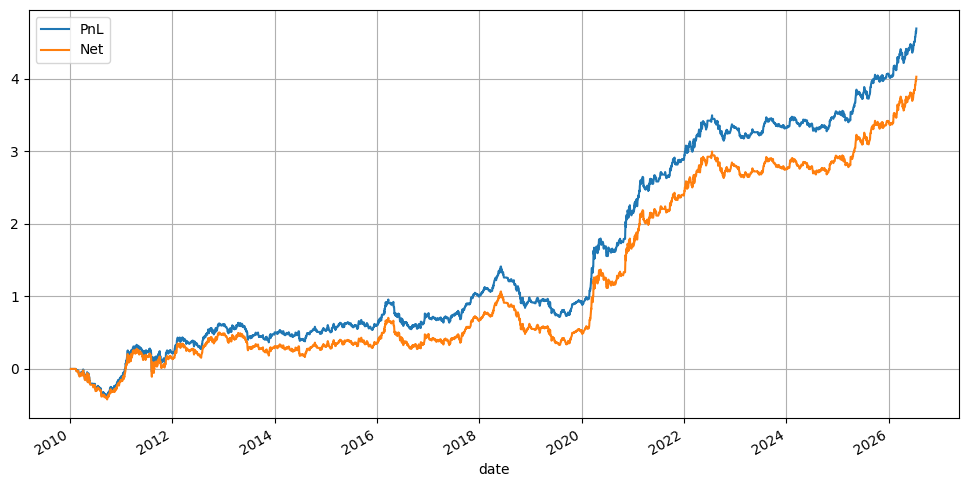

In [ ]:
crack = df_m['crack_01']

tickers = ['PSX', 'DK', 'DINO', 'MPC', 'PBF', 'VLO']

results = {}
results_net = {}
positions = {}

for ticker in tickers:

    df_st = load_stock_data(ticker)
    df_st = df_st.set_index('date').sort_index()
    df_st['crack'] = crack
    df_st['cl_ret'] = df_m['cl_ret']
    df_st['ho_ret'] = df_m['ho_ret']


    for mv in [2, 3, 5, 10, 20, 30, 50, 60, 100]:
        df_st[f'mv_{mv}'] = df_st['crack'].rolling(mv, min_periods=mv//2).mean()
        df_st[f'sd_{mv}'] = df_st['crack'].rolling(mv, min_periods=mv//2).std()

    df_st['sig_L'] = np.nan
    df_st['sig_S'] = np.nan

    df_st.loc[df_st['mv_3'] > df_st['mv_50'], 'sig_L'] = +1.0 # * 0.05 / df_st['raw_return'].rolling(60, min_periods=20).std()
    df_st.loc[df_st['mv_3'] < df_st['mv_30'], 'sig_L'] = 0.

    df_st.loc[df_st['mv_3'] < df_st['mv_50'], 'sig_S'] = -0.5 # * 0.05 / df_st['raw_return'].rolling(60, min_periods=20).std()
    df_st.loc[df_st['mv_3'] > df_st['mv_30'], 'sig_S'] = 0.

    # ret_col = 'residual_return_mktsec_w12m'
    # ret_col = 'residual_return_mkt_w12m'
    ret_col = 'raw_return'


    df_st['sig'] = df_st['sig_L'].ffill().fillna(0) + df_st['sig_S'].ffill().fillna(0)
    df_st['pos'] = df_st['sig'].ffill().fillna(0).shift(2)
    df_st['pnl'] = df_st['pos'].shift(1) * df_st[ret_col]

    df_st['slip'] = df_st['pos'].diff().abs() * 25 * 1e-4
    df_st['net'] = df_st['pnl'] - df_st['slip']

    results[ticker] = df_st['pnl'].copy()
    results_net[ticker] = df_st['net'].copy()
    positions[ticker] = df_st['pos'].copy()


df = pd.DataFrame(results)
df_net = pd.DataFrame(results_net)
df_pos = pd.DataFrame(positions)

df_tot = pd.DataFrame({
    'PnL': df.mean(axis=1),
    'Net': df_net.mean(axis=1),
})

df_tot.cumsum().plot(figsize=(12, 6), grid=True)

x = df_tot.loc[df_tot.index >= '2020-01-01']

sharpe = x.mean() / x.std() * np.sqrt(252)

sharpe

In [275]:
df_01 = df_tot.copy()

In [273]:
df_02 = df_tot.copy()

In [271]:
df_03 = df_tot.copy()

<Axes: xlabel='date'>

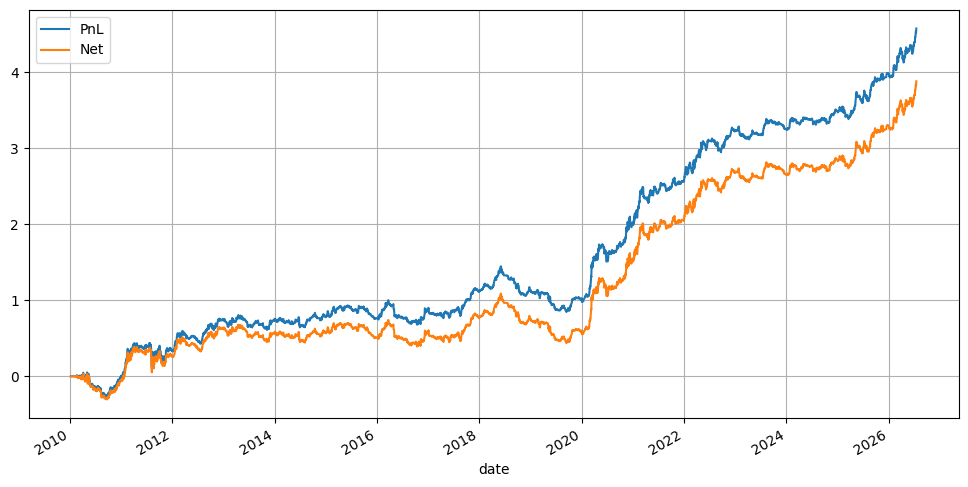

In [276]:
df = df_01 * 0.5 + df_02 * 0.2 + df_03 * 0.3
df.cumsum().plot(figsize=(12, 6), grid=True)

In [277]:
x = df.loc[df_tot.index >= '2020-01-01']

sharpe = x.mean() / x.std() * np.sqrt(252)

sharpe

PnL    1.770855
Net    1.634497
dtype: float64

In [5]:
def load_fut_continuous_data(ticker: str, root=ROOT):
    p = root / f'data/comm/carry_data/{ticker}.csv'
    df = pd.read_csv(p, index_col='date', parse_dates=['date'])
    return df.sort_index()


def load_stock_data(ticker, comm="CL", root=ROOT):
    comm = comm.upper()
    cache_path = root / f"data/cache/feature_return/{comm}-multi_return.parquet"

    df = pd.read_parquet(cache_path)
    out = df[df["ticker"].eq(ticker)].copy()
    if not out.empty:
        out["date"] = pd.to_datetime(out["date"]).dt.normalize()
        return out.sort_values("date").reset_index(drop=True)

    # Hedge/ETF fallback keeps notebook use working before a cache rebuild.
    if ticker in {"SPY", "XLE", "XME", "QQQ", "CRAK"}:
        path = root / f"data/equity/yfinance/{ticker}.csv"
        out = pd.read_csv(path)
        out["date"] = pd.to_datetime(out["date"]).dt.normalize()
        price_col = "adj_close" if "adj_close" in out.columns else "close"
        price = pd.to_numeric(out[price_col], errors="coerce")
        out["raw_return"] = np.log(price).diff()
        return out.sort_values("date").reset_index(drop=True)

    return out


def load_feature_data(feature_name, symbol="CL", root=ROOT):
    path = root / "data/processed/commodity_signals.parquet"
    df = pd.read_parquet(path)

    df["date"] = pd.to_datetime(df["date"])

    if "symbol" in df.columns:
        df = df[df["symbol"].eq(symbol)].copy()

    if feature_name not in df.columns:
        matches = [c for c in df.columns if feature_name.lower() in c.lower()]
        raise KeyError(f"{feature_name} not found. Similar columns: {matches[:20]}")

    out = df[["date", "symbol", feature_name]].copy()
    out = out.rename(columns={feature_name: "feature_value"})
    out["feature_name"] = feature_name
    out["feature_source_valid"] = out["feature_value"].notna()

    # 防止同一个 symbol/date 仍有重复
    out = out.sort_values("date").drop_duplicates(["date", "symbol"], keep="last")
    out = out.sort_values("date").reset_index(drop=True)

    return out


def join_stock_feature(stock_df, feature_df, how="left"):
    s = stock_df.copy()
    f = feature_df.copy()

    s["date"] = pd.to_datetime(s["date"])
    f["date"] = pd.to_datetime(f["date"])

    out = s.merge(f, on="date", how=how)
    out = out.sort_values("date").reset_index(drop=True)

    feature_name = f["feature_name"].dropna().iloc[-1]

    calendar_like = (
        feature_name == "calendar_dec_annualized_carry"
        or feature_name.startswith("next_dec_")
        or feature_name.startswith("mar_dec_")
        or feature_name.startswith("jun_dec_")
        or feature_name.startswith("sep_dec_")
    )

    if calendar_like:
        valid_state = out["feature_source_valid"].ffill().fillna(False).astype(bool)
        out["feature_value"] = out["feature_value"].ffill().where(valid_state)
    else:
        out["feature_value"] = out["feature_value"].ffill()

    return out


In [11]:
def shipping_sticky_signal(carry, m0_log_ret_5d):
    carry = pd.to_numeric(carry, errors="coerce")
    momentum = pd.to_numeric(m0_log_ret_5d, errors="coerce")
    carry_change_20d = carry.diff(20)

    long_entry = (momentum < 0) & (carry < 0)
    short_entry = (momentum > 0) & (carry > 0)
    reset_state = carry_change_20d > 0.01
    invalid = carry.isna() | momentum.isna()

    # Priority: short_entry > reset_state > long_entry
    state_update = pd.Series(np.nan, index=carry.index, dtype=float)
    state_update.loc[long_entry] = 1.0
    state_update.loc[reset_state] = 0.0
    state_update.loc[short_entry] = -1.0
    state_update.loc[invalid] = 0.0

    return state_update.ffill().fillna(0.0)

def calc_sig(
    category: str = 'refiner', 
    comm:     str = 'CL',
    start:    str = '2010-01-01',
    ret_col:  str = 'residual_return_mktsec_w12m',
) -> tuple[pd.DataFrame, pd.DataFrame]:

    config = SLEEVE_CONFIG[category]
    tickers = config['tickers']
    threshold = config['threshold']
    side_mult = config['side_mult']
    feature = config['feature']
    weights = config['weights']

    print(f"comm: {comm}, category: {category}, threshold: {threshold}, side_mult: {side_mult}, feature: {feature}")

    sig, ret = {}, {}
    for ticker in tickers:
        # df = load_stock_data(ticker).set_index('date').sort_index()
        df = load_stock_data(ticker, comm=comm).set_index("date").sort_index()

        # Cache features are mapped from commodity arrival timestamps to the
        # first eligible stock session. Do not merge carry_data on settlement date.
        feature_col = f'feature_value__{feature}'
        if category == 'shipping':
            required = [
                'feature_value__carry',
                'feature_value__front_log_ret_5d_v2',
            ]
        else:
            required = [feature_col]
        missing = [col for col in required if col not in df.columns]
        if missing:
            raise KeyError(f'Missing arrival-safe cache features: {missing}')

        df['feature_value'] = df[feature_col]
        df['feature_source_valid'] = df['feature_value'].notna()

        df['sig_L'] = np.nan
        df['sig_S'] = np.nan

        if category in ['chemical']:
            df.loc[(df['feature_value'].diff(30) < 0.0) & (df['feature_value'] > -0.0), 'sig_L'] = +1 * side_mult
            df.loc[(df['feature_value']  <= -0.01), 'sig_L'] = 0
            df.loc[(df['feature_value'].diff(30) > 0.0) & (df['feature_value'] < +0.0), 'sig_S'] = -1 * side_mult
            df.loc[(df['feature_value']  >= -0.05), 'sig_S'] = 0

            invalid = df[required].isna().any(axis=1)
            df.loc[invalid, ['sig_L', 'sig_S']] = 0
            df['sig'] = df['sig_S'].ffill().fillna(0) + df['sig_L'].ffill().fillna(0)
        elif category in ['refiner']:
            df.loc[df["feature_value"] > threshold,  "sig_L"] = +1 * side_mult
            df.loc[df["feature_value"] < 0,          "sig_L"] = 0
            df.loc[df["feature_value"] < -threshold, "sig_S"] = -1 * side_mult
            df.loc[df["feature_value"] > 0,          "sig_S"] = 0 

            invalid = df[required].isna().any(axis=1)
            df.loc[invalid, ['sig_L', 'sig_S']] = 0
            df['sig'] = df['sig_S'].ffill().fillna(0) + df['sig_L'].ffill().fillna(0)
        elif category in ['psx_ref']:
            df.loc[df["feature_value"] > threshold,  "sig_L"] = +1 * side_mult
            df.loc[df["feature_value"] < 0,          "sig_L"] = 0
            df.loc[df["feature_value"] < -threshold, "sig_S"] = -1 * side_mult
            df.loc[df["feature_value"] > 0,          "sig_S"] = 0 

            invalid = df[required].isna().any(axis=1)
            df.loc[invalid, ['sig_L', 'sig_S']] = 0
            df['sig'] = df['sig_S'].ffill().fillna(0) + df['sig_L'].ffill().fillna(0)
        elif category in ['shipping']:
            carry = df["feature_value__carry"]
            momentum = df["feature_value__front_log_ret_5d_v2"]
            df["sig"] = shipping_sticky_signal(carry, momentum)
        elif category == 'service':
            vol = df['feature_value'].rolling(60, min_periods=30).std()
            df.loc[df['feature_value'] > +vol * 2.0, 'sig_L'] = +1 * side_mult
            df.loc[df['feature_value'] < -vol * 1.0, 'sig_L'] = 0
            df.loc[df['feature_value'] < -vol * 2.0, 'sig_S'] = -1 * side_mult
            df.loc[df['feature_value'] > +vol * 1.0, 'sig_S'] = 0

            invalid = df[required].isna().any(axis=1)
            df.loc[invalid, ['sig_L', 'sig_S']] = 0
            df['sig'] = df['sig_S'].ffill().fillna(0) + df['sig_L'].ffill().fillna(0)

        else:
            df.loc[df['feature_value'] > threshold,  'sig_L'] = +1 * side_mult
            df.loc[df['feature_value'] < 0,          'sig_L'] =  0
            df.loc[df['feature_value'] < -threshold, 'sig_S'] = -1 * side_mult
            df.loc[df['feature_value'] > 0,          'sig_S'] =  0

            invalid = df[required].isna().any(axis=1)
            df.loc[invalid, ['sig_L', 'sig_S']] = 0
            df['sig'] = df['sig_S'].ffill().fillna(0) + df['sig_L'].ffill().fillna(0)

        sig[ticker] = df['sig'] * weights[ticker]
        ret[ticker] = df[ret_col]

    df_sig= pd.DataFrame(sig).sort_index().fillna(0)
    df_ret= pd.DataFrame(ret).sort_index()
    return df_sig.loc[df_sig.index >= start], df_ret.loc[df_ret.index >= start]


def calc_pos(df_sig, fixed_hold=None, hold_days: int = 10, delay: int = 1) -> pd.DataFrame:
    if fixed_hold is None:
        fixed_hold = []

    tickers = df_sig.columns.tolist()
    pos = {}

    for ticker in tickers:
        if ticker in fixed_hold:
            active_until = -1
            active_signal = 0.0

            sig = df_sig[ticker].fillna(0).to_numpy(dtype=float)
            tmp = np.zeros(len(sig), dtype=float)

            for i, s in enumerate(sig):
                if s == 0 or np.isnan(s):
                    continue

                start = i + delay
                end = start + hold_days

                if start >= len(sig):
                    continue

                # 当前信号还在上一段持仓窗口内
                if i <= active_until:
                    # 只有同方向且刚好无缝接续，才延长持仓
                    if s == active_signal and start == active_until + 1:
                        end = min(end, len(sig))
                        tmp[start:end] = s
                        active_until = end - 1
                    continue

                end = min(end, len(sig))
                tmp[start:end] = s
                active_until = end - 1
                active_signal = s

            pos[ticker] = pd.Series(tmp, index=df_sig.index)
        else:
            pos[ticker] = df_sig[ticker].shift(delay).fillna(0)

    return pd.DataFrame(pos, index=df_sig.index)


def calc_pos_with_future(
    df_sig,
    future_sessions,
    fixed_hold=None,
    hold_days=10,
    delay=1,
):
    future = pd.DatetimeIndex(future_sessions)

    if future.intersection(df_sig.index).size:
        raise ValueError("future_sessions already exist in df_sig")

    # 空行只用于让最后一个signal经过shift落到未来日期。
    future_rows = pd.DataFrame(
        0.0,
        index=future,
        columns=df_sig.columns,
    )

    df_sig_extended = pd.concat(
        [df_sig, future_rows],
        axis=0,
    ).sort_index()

    df_pos_extended = calc_pos(
        df_sig_extended,
        fixed_hold=fixed_hold,
        hold_days=hold_days,
        delay=delay,
    )

    return (
        df_pos_extended.reindex(df_sig.index),  # 历史回测
        df_pos_extended.reindex(future),        # 未来targets
    )


def calc_pnl(df_pos, df_ret, slip: float = 25.) -> tuple[pd.DataFrame, pd.DataFrame]:

    df_pnl = df_pos.shift(1).fillna(0).mul(df_ret)

    df_diff = df_pos.fillna(0).diff().fillna(0).abs()
    df_slip = df_diff * slip / 1e4

    return df_pnl, df_pnl - df_slip


def calc_ret(ds: pd.Series) -> float:
    return ds.sum()

def calc_std(ds: pd.Series) -> float:
    return ds.std() * np.sqrt(252.)

def calc_maxdd(ds: pd.Series) -> float:
    return (ds.cumsum().cummax() - ds.cumsum()).max()

def calc_calmar(ds: pd.Series) -> float:
    return ds.mean() * 252. / calc_maxdd(ds)

def calc_sharpe(ds: pd.Series) -> float:
    return ds.mean() / ds.std() * np.sqrt(252.)

def calc_stats(ds: pd.Series) -> pd.DataFrame:
    years = sorted(set(ds.index.year))
    indices, returns, vols, maxdds, sharpes, calmars = [], [], [], [], [], []

    for yr in years:
        ds_yr = ds.loc[ds.index.year == yr]
        indices += str(yr),
        returns += calc_ret(ds_yr),
        vols += calc_std(ds_yr),
        maxdds += calc_maxdd(ds_yr),
        calmars += calc_calmar(ds_yr),
        sharpes += calc_sharpe(ds_yr),

    indices += 'Total',
    returns += calc_ret(ds),
    vols += calc_std(ds),
    maxdds += calc_maxdd(ds),
    calmars += calc_calmar(ds),
    sharpes += calc_sharpe(ds),

    return pd.DataFrame({
        'Year': indices,
        'ret': returns,
        'vol': vols,
        'maxdd': maxdds,
        'calmar': calmars,
        'sharpe': sharpes,
    }).set_index('Year').round(3)

In [12]:
target_date = pd.Timestamp("2026-07-20")


comm: CL, category: psx_ref, threshold: 0.01, side_mult: 1, feature: activity_deferred_annualized_carry_chg_21d


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2012,0.073,0.101,0.056,1.806,1.004
2013,0.190,0.222,0.262,0.727,0.859
2014,-0.037,0.153,0.131,-0.283,-0.243
2015,0.266,0.175,0.118,2.255,1.520
2016,0.121,0.152,0.179,0.677,0.797
2017,-0.040,0.106,0.108,-0.370,-0.377
2018,-0.051,0.154,0.238,-0.213,-0.330
2019,0.303,0.130,0.083,3.671,2.330
2020,0.228,0.331,0.161,1.410,0.685


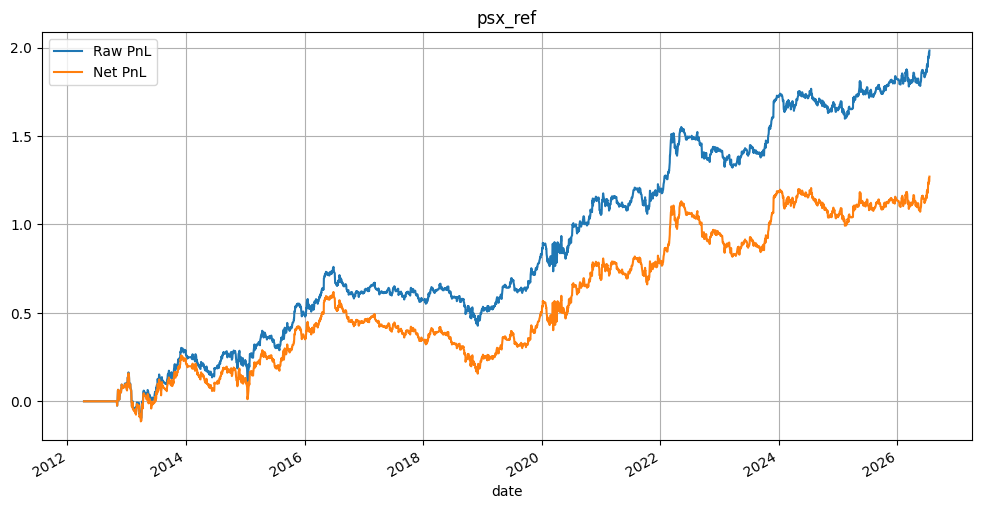

In [13]:
df_psx_ref, df_ret = calc_sig('psx_ref', 'CL')

df_psx_ref_pos, df_psx_ref_target = calc_pos_with_future(df_psx_ref.rolling(5).mean(), [target_date])

df_pnl, df_net = calc_pnl(df_psx_ref_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='psx_ref', grid=True)

df_net.to_csv('sim_results/psx_ref.csv', index=True)

calc_stats(df_pnl.sum(axis=1))

comm: HO, category: refiner, threshold: 0.01, side_mult: 1, feature: front_third_annualized_carry_chg_21d


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2010,-0.108,0.137,0.182,-0.596,-0.792
2011,-0.036,0.232,0.202,-0.179,-0.156
2012,0.019,0.187,0.161,0.122,0.105
2013,0.045,0.225,0.175,0.259,0.201
2014,0.183,0.250,0.208,0.879,0.729
2015,0.271,0.244,0.269,1.005,1.111
2016,0.615,0.344,0.155,3.978,1.784
2017,0.320,0.216,0.167,1.929,1.492
2018,0.254,0.241,0.220,1.160,1.058


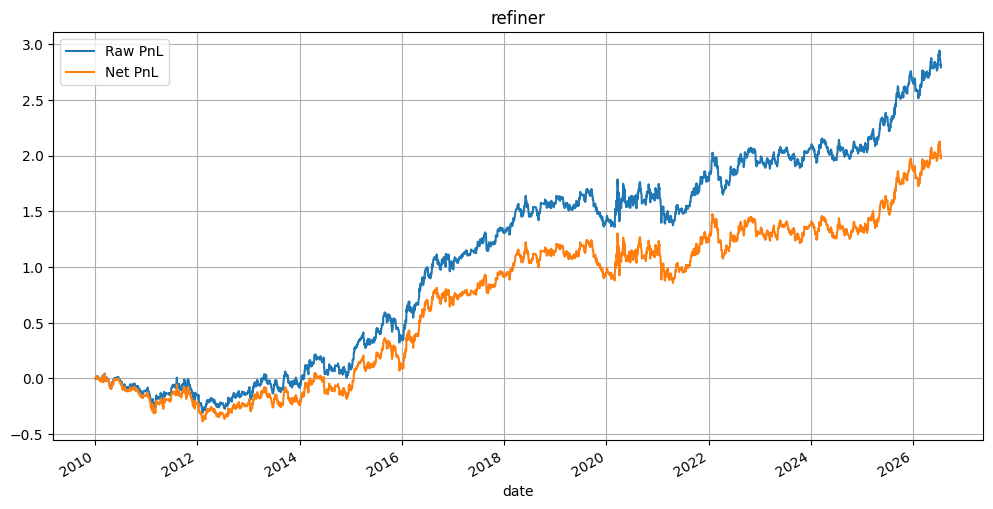

In [14]:
df_refiner, df_ret = calc_sig('refiner', 'HO')

df_refiner_pos, df_refiner_target = calc_pos_with_future(df_refiner.rolling(5).mean(), [target_date])

df_pnl, df_net = calc_pnl(df_refiner_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='refiner', grid=True)

df_net.to_csv('sim_results/refiner.csv', index=True)

calc_stats(df_pnl.sum(axis=1))

comm: XB, category: fuel, threshold: 0.06, side_mult: -1, feature: front_third_annualized_carry


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2010,0.144,0.165,0.097,1.479,0.875
2011,0.275,0.142,0.052,5.240,1.928
2012,-0.059,0.142,0.185,-0.322,-0.419
2013,0.128,0.110,0.064,1.993,1.168
2014,0.087,0.142,0.115,0.761,0.614
2015,-0.052,0.180,0.203,-0.257,-0.290
2016,0.015,0.183,0.215,0.069,0.081
2017,-0.008,0.190,0.195,-0.043,-0.044
2018,0.136,0.170,0.120,1.137,0.806


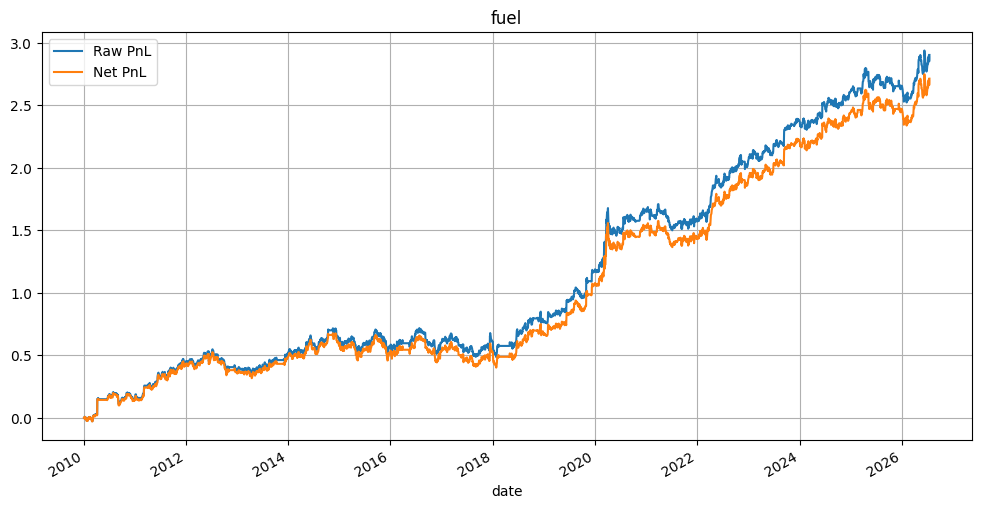

In [15]:
df_fuel, df_ret = calc_sig('fuel', 'XB')

df_fuel_pos, df_fuel_target = calc_pos_with_future(df_fuel, [target_date], df_fuel.columns.tolist(), 10)
df_pnl, df_net = calc_pnl(df_fuel_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='fuel', grid=True)


df_net.to_csv('sim_results/fuel.csv', index=True)

calc_stats(df_net.sum(axis=1))

comm: CL, category: service, threshold: 0.1, side_mult: -1, feature: carry_chg_21d


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2010,0.208,0.110,0.050,4.195,1.891
2011,-0.033,0.093,0.118,-0.284,-0.358
2012,0.032,0.033,0.020,1.628,0.971
2013,0.080,0.063,0.033,2.402,1.275
2014,0.072,0.060,0.034,2.139,1.198
2015,0.056,0.076,0.055,1.026,0.735
2016,0.033,0.115,0.097,0.338,0.285
2017,0.026,0.051,0.042,0.611,0.500
2018,0.280,0.143,0.057,4.969,1.974


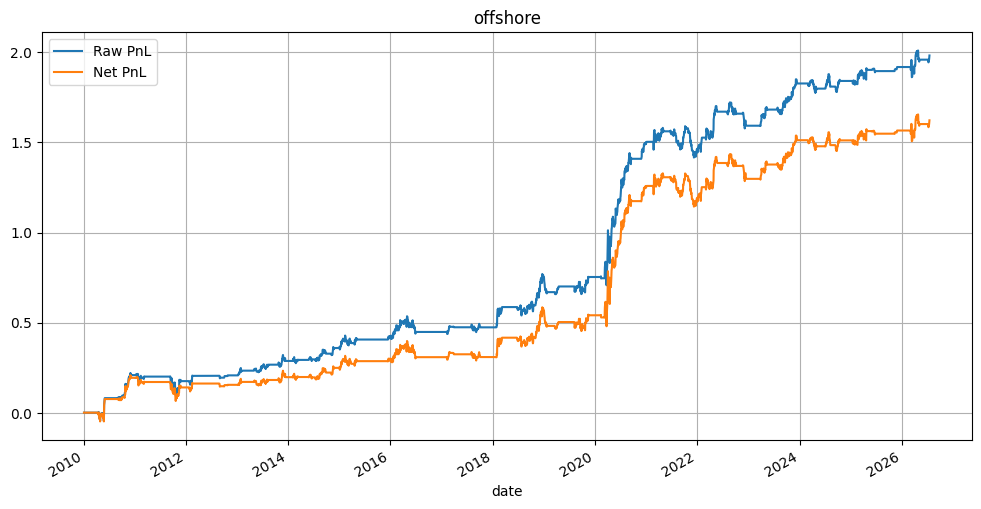

In [16]:
df_service, df_ret = calc_sig('service', 'CL')

df_service_pos, df_service_target = calc_pos_with_future(df_service.rolling(2).mean(), [target_date])
df_pnl, df_net = calc_pnl(df_service_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='offshore', grid=True)

df_net.to_csv('sim_results/offshore.csv', index=True)

calc_stats(df_pnl.sum(axis=1))

comm: CL, category: shipping, threshold: 0.01, side_mult: -1, feature: carry


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2010,0.066,0.133,0.125,0.531,0.499
2011,0.566,0.329,0.338,1.672,1.717
2012,0.313,0.172,0.093,3.398,1.835
2013,0.051,0.250,0.254,0.201,0.204
2014,0.053,0.190,0.125,0.425,0.280
2015,-0.136,0.189,0.217,-0.628,-0.719
2016,0.683,0.228,0.101,6.763,2.994
2017,0.123,0.166,0.161,0.766,0.743
2018,-0.095,0.124,0.170,-0.557,-0.767


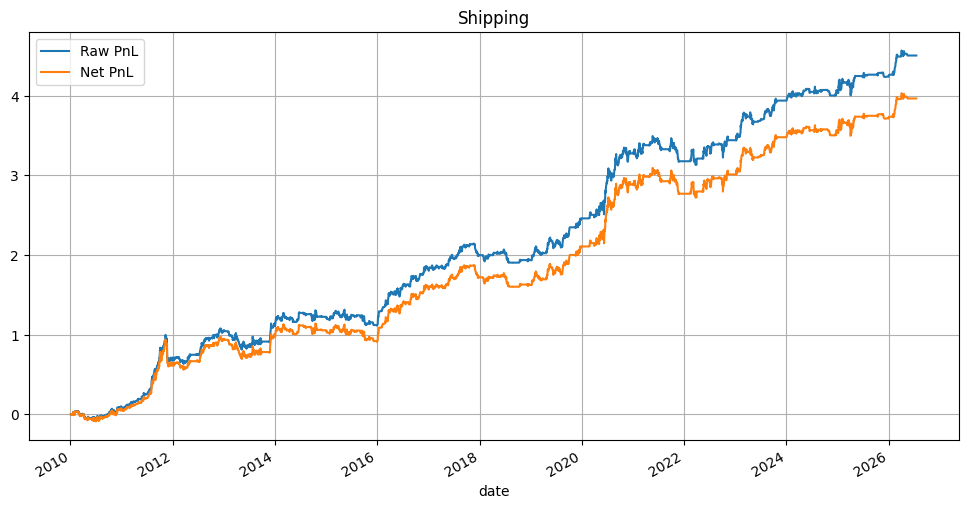

In [17]:
df_ship, df_ret = calc_sig('shipping', 'CL')

# df_ship_pos = calc_pos(df_ship)
df_ship_pos, df_ship_target = calc_pos_with_future(df_ship.rolling(5).mean(), [target_date])
df_pnl, df_net = calc_pnl(df_ship_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='Shipping', grid=True)

df_net.to_csv('sim_results/shipping.csv', index=True)
calc_stats(df_net.sum(axis=1))

comm: CL, category: chemical, threshold: 0.02, side_mult: 1, feature: carry
         ret    vol  maxdd  calmar  sharpe
Year                                      
2010   0.151  0.112  0.083   1.806   1.339
2011  -0.036  0.164  0.260  -0.140  -0.222
2012   0.029  0.098  0.109   0.269   0.300
2013  -0.022  0.048  0.068  -0.319  -0.455
2014  -0.049  0.065  0.099  -0.493  -0.747
2015   0.082  0.109  0.063   1.297   0.755
2016  -0.100  0.143  0.162  -0.616  -0.699
2017   0.183  0.093  0.052   3.525   1.979
2018   0.203  0.093  0.056   3.678   2.195
2019  -0.047  0.078  0.098  -0.481  -0.606
2020   0.483  0.203  0.131   3.670   2.371
2021   0.080  0.134  0.073   1.094   0.596
2022   0.343  0.218  0.150   2.300   1.579
2023   0.005  0.042  0.034   0.149   0.120
2024   0.381  0.141  0.099   3.826   2.695
2025   0.532  0.292  0.126   4.252   1.835
2026   0.308  0.161  0.064   8.924   3.571
Total  2.526  0.143  0.272   0.563   1.067


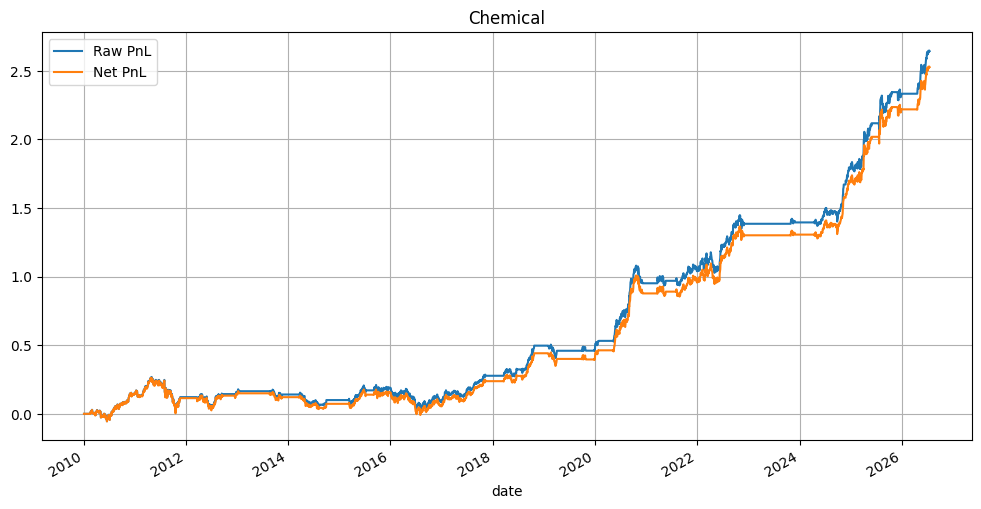

In [18]:
df_chem, df_ret = calc_sig('chemical', 'CL')

# df_chem_pos, df_chem_target = calc_pos_with_future(df_chem, [target_date])
df_chem_pos, df_chem_target = calc_pos_with_future(df_chem, [target_date], df_chem.columns.tolist(), 21)
df_pnl, df_net = calc_pnl(df_chem_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='Chemical', grid=True)


df_net.to_csv('sim_results/chemical.csv', index=True)
print(calc_stats(df_net.sum(axis=1)))

comm: CL, category: metals, threshold: 0.015, side_mult: -1, feature: next_dec_annualized_carry_gap_le_9m_v2


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2010,-0.113,0.195,0.322,-0.351,-0.579
2011,-0.098,0.206,0.210,-0.464,-0.475
2012,0.323,0.151,0.096,3.382,2.149
2013,0.071,0.144,0.113,0.632,0.493
2014,-0.105,0.147,0.250,-0.421,-0.716
2015,0.069,0.257,0.214,0.323,0.270
2016,0.447,0.299,0.262,1.707,1.492
2017,-0.093,0.249,0.253,-0.370,-0.376
2018,0.082,0.204,0.159,0.520,0.405


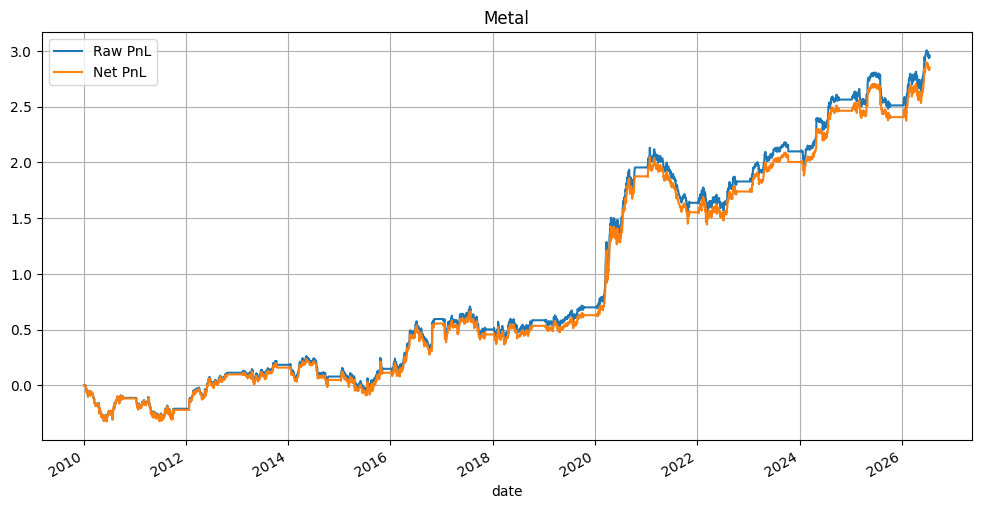

In [19]:
df_met, df_ret = calc_sig('metals', 'CL')

df_met_pos, df_met_target = calc_pos_with_future(df_met, [target_date], df_met.columns.tolist(), 21)
df_pnl, df_net = calc_pnl(df_met_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='Metal', grid=True)

df_net.to_csv('sim_results/metals.csv', index=True)
calc_stats(df_pnl.sum(axis=1))

comm: CL, category: bwt, threshold: 0.02, side_mult: -1, feature: brent_wti_carry_spread


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2010,0.102,0.110,0.090,1.137,0.928
2011,-0.135,0.135,0.210,-0.641,-0.997
2012,0.059,0.119,0.124,0.482,0.504
2013,-0.251,0.116,0.317,-0.793,-2.165
2014,0.189,0.147,0.108,1.754,1.285
2015,-0.165,0.227,0.230,-0.718,-0.728
2016,0.390,0.296,0.157,2.482,1.318
2017,0.107,0.177,0.212,0.506,0.607
2018,0.120,0.240,0.190,0.636,0.504


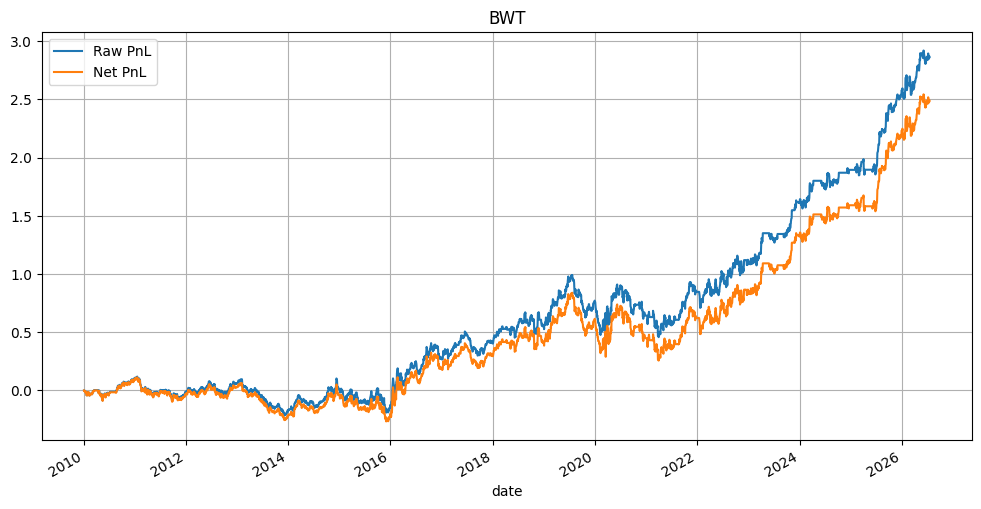

In [20]:
df_bwt, df_ret = calc_sig('bwt', 'CL')

df_bwt_pos, df_bwt_target = calc_pos_with_future(df_bwt, [target_date], df_bwt.columns.tolist(), 10)
df_pnl, df_net = calc_pnl(df_bwt_pos, df_ret)
pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(figsize=(12, 6), title='BWT', grid=True)

df_net.to_csv('sim_results/bwt.csv', index=True)
calc_stats(df_net.sum(axis=1))

In [21]:
# V32_WEIGHTS = {
#     "refiner":    0.24,
#     "shipping":   0.23,
#     "chemical":   0.22,
#     "services":   0.09,
#     "metals":     0.11,
#     "bwt":        0.06,
#     "fuel":       0.03,
# }

# V32_WEIGHTS = {
#     "chemical":   0.28,
#     "shipping":   0.20,
#     "refiner":    0.20,
#     "services":   0.10,
#     "metals":     0.10,
#     "bwt":        0.06,
#     "fuel":       0.04,
# }


V32_WEIGHTS = {
    "chemical":   0.28,
    "shipping":   0.25,
    "refiner":    0.10,
    "psx_ref":    0.05,
    "services":   0.10,
    "metals":     0.10,
    "bwt":        0.06,
    "fuel":       0.04,
}


# V32_WEIGHTS = {
#     "refiner":    0.30,
#     "shipping":   0.25,
#     "chemical":   0.25,
#     "services":   0.10,
#     "metals":     0.10,
#     "bwt":        0.0,
#     "fuel":       0.0,
# }


POSITIONS = {
    "refiner":    df_refiner_pos,
    "psx_ref":    df_psx_ref_pos,
    "fuel":       df_fuel_pos,
    "services":   df_service_pos,
    "shipping":   df_ship_pos,
    "chemical":   df_chem_pos,
    "metals":     df_met_pos,
    "bwt":        df_bwt_pos,
}

TARGETS = {
    "refiner":    df_refiner_target,
    "psx_ref":    df_psx_ref_target,
    "fuel":       df_fuel_target,
    "services":   df_service_target,
    "shipping":   df_ship_target,
    "chemical":   df_chem_target,
    "metals":     df_met_target,
    "bwt":        df_bwt_target,
}

In [22]:
print(sum(V32_WEIGHTS.values()))

MAX_NAME_WEIGHT = 0.05

0.9800000000000001


         ret    vol  maxdd  calmar  sharpe
Year                                      
2010   0.051  0.042  0.051   0.997   1.206
2011   0.083  0.074  0.060   1.377   1.119
2012   0.103  0.049  0.016   6.523   2.117
2013   0.005  0.057  0.067   0.073   0.086
2014   0.011  0.051  0.044   0.263   0.227
2015   0.022  0.062  0.066   0.328   0.353
2016   0.249  0.073  0.037   6.796   3.408
2017   0.093  0.053  0.034   2.767   1.768
2018   0.098  0.049  0.044   2.206   1.979
2019   0.120  0.059  0.034   3.493   2.032
2020   0.507  0.137  0.069   7.353   3.686
2021  -0.020  0.080  0.071  -0.285  -0.253
2022   0.208  0.097  0.057   3.695   2.148
2023   0.208  0.064  0.029   7.226   3.292
2024   0.169  0.065  0.040   4.188   2.608
2025   0.263  0.100  0.036   7.303   2.651
2026   0.214  0.079  0.020  19.553   5.066
Total  2.382  0.074  0.089   1.627   1.953


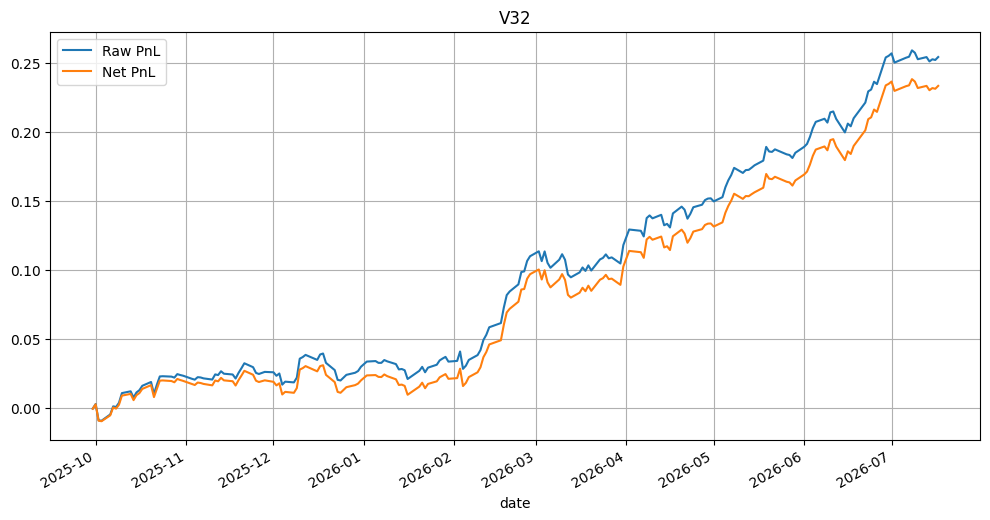

In [23]:
positions, returns, targets = {}, {}, {}

for sec, df_pos in POSITIONS.items():
    tickers = df_pos.columns.tolist()
    for ticker in tickers:
        positions[ticker] = df_pos[ticker] * V32_WEIGHTS[sec]
        targets[ticker] = TARGETS[sec][ticker] * V32_WEIGHTS[sec]

        df_st = load_stock_data(ticker).set_index('date')
        returns[ticker] = df_st['residual_return_mktsec_w12m']


df_pos = pd.DataFrame(positions).clip(lower=-MAX_NAME_WEIGHT, upper=MAX_NAME_WEIGHT)
df_tar = pd.DataFrame(targets).clip(lower=-MAX_NAME_WEIGHT, upper=MAX_NAME_WEIGHT)

df_ret = pd.DataFrame(returns)
df_pnl, df_net = calc_pnl(df_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).iloc[-200:].cumsum().plot(figsize=(12, 6), title='V32', grid=True)

df_net.to_csv('sim_results/v32.csv', index=True)
print(calc_stats(df_net.sum(axis=1)))

In [24]:
print(df_tar.T)

      2026-07-20
DINO      -0.030
DK        -0.040
PBF       -0.030
PSX        0.010
MUSA       0.016
CASY       0.024
FTI       -0.025
OII       -0.025
SLB       -0.025
HAL       -0.025
DHT        0.000
FRO        0.000
TNK        0.000
STNG       0.000
INSW       0.000
AVNT      -0.014
CE        -0.028
DOW       -0.050
EMN       -0.028
HUN       -0.028
LYB       -0.050
WLK       -0.050
ATI        0.050
CRS        0.045
ERO       -0.030
TECK      -0.030


In [25]:
df_pos.to_csv("sim_results/v32_pos.csv", index_label="date")

In [30]:
df_pnl.sum(axis=1).tail(5)

date
2026-07-13    0.001551
2026-07-14   -0.003151
2026-07-15    0.001558
2026-07-16   -0.000504
2026-07-17    0.002146
dtype: float64

In [27]:
x = df_net.sum(axis=1).to_frame('net_pnl')
x['year-month'] = x.index.strftime('%Y-%m')

x.groupby('year-month').sum().round(3).tail(20)

,net_pnl
year-month,
2024-12,0.032
2025-01,0.026
2025-02,0.024
2025-03,-0.005
2025-04,0.068
2025-05,0.062
2025-06,-0.001
2025-07,0.029
2025-08,0.009


In [28]:
print(df_net.iloc[-1])

DINO   -0.000269
DK     -0.000130
PBF    -0.000091
PSX     0.000635
MUSA    0.000384
CASY    0.001017
FTI     0.000105
OII     0.000110
SLB     0.000184
HAL     0.000059
DHT    -0.000000
FRO    -0.000000
TNK    -0.000000
STNG   -0.000000
INSW   -0.000000
AVNT    0.000303
CE      0.000214
DOW    -0.000582
EMN     0.000063
HUN    -0.000080
LYB    -0.000647
WLK    -0.000173
ATI     0.000617
CRS     0.000513
ERO    -0.000041
TECK   -0.000090
Name: 2026-07-17 00:00:00, dtype: float64
